In [2]:
import numpy as np
from scipy.ndimage import gaussian_filter

# my imports
from occupancy import *
from plotting3d import *
from generate_objects import *

In [3]:
%load_ext autoreload 
%autoreload 2

In [4]:
# "Latex style"
import matplotlib
matplotlib.rcParams.update({
    "font.family": "serif",
    "text.usetex": True,
}
)

# Setup

In [44]:
alpha_xtrs = np.linspace(1e-2,1, 5)
alpha_xtrs = np.linspace(1e-2,1, 150)
alpha_xtrs = np.linspace(1e-2,1, 50)

alpha_0 = 0.27
alpha = 1
noise_level = 0.0
offset = False
# from generate_objects import generate_obj_cistrans_v2
# obj0, obj1, f_dark, f_light, delta_fa_abs, imagetype =  generate_obj_cistrans_v2(alpha, noise_level, offset)



if "2d" in imagetype:
    strict = 0.005
    lax = 0.001
    mask_thresh = 0.0003
else:
    strict = 0.05 * alpha/alpha_0
    lax = 0.015 * alpha/alpha_0
    mask_thresh = 0.03 * alpha/alpha_0


dataloc = "../synthetic_cistrans/"
pdbname_dark = dataloc+"trans.pdb"
pdbname_light = dataloc+"100ps.pdb"
struc_dark = gemmi.read_structure(pdbname_dark)
struc_light = gemmi.read_structure(pdbname_light)

In [53]:
import os

def write_scaleit_input(mtz_in, b_scaling, low_res, high_res):
    mtz_out    = "from_scaleit.mtz"
    script_out = 'launch_scaleit.sh'
    i = open(script_out,'w')
    i.write("#!/bin/bash\n\
scaleit HKLIN %s HKLOUT %s <<eof > scaleit.log\n\
REFINE %s \n\
RESOLUTION %.2f %.2f \n\
LABIN FP = F SIGFP = SIGF  FPH1 = F2 SIGFPH1 = SIGF2 \n\
eof" %(mtz_in, mtz_out, b_scaling, low_res, high_res))
    i.close()
    return mtz_out, script_out

def run_scaleit(struc_dark, struc_light, b_scaling:str, low_res=None, high_res=None, log=sys.stdout):
    if b_scaling   == 'isotropic':
        b_scaling  = 'ISOTROPIC'
    elif b_scaling == 'anisotropic':
        b_scaling  = 'ANISOTROPIC'
    else:
        b_scaling  = 'SCALE'
        
    mtz_to_scaleit, struc_vals = comb_strucs(struc_dark, struc_light)
    dmax, dmin = 50, 1
    if low_res == None:
        low_res = dmax
    if high_res == None:
        high_res = dmin
        
    mtz_fromscaleit, script_scaleit = write_scaleit_input(mtz_to_scaleit, b_scaling, low_res, high_res)

    os.system("chmod +x %s" %(script_scaleit))
    print("Running scaleit, see %s" %(script_scaleit), file=log)
    os.system("./%s" %(script_scaleit))

    df = rs.read_mtz(mtz_fromscaleit)
    
    print(df)
    return df

def comb_strucs(struc1,struc2):
    hs_limit=1.5
    map_vals = meteor.sfcalc.gemmi_structure_to_calculated_map(struc1, high_resolution_limit=hs_limit)
    map_vals2 = meteor.sfcalc.gemmi_structure_to_calculated_map(struc2, high_resolution_limit=hs_limit)
    struc_vals=rs.DataSet(map_vals)
    struc_vals2=rs.DataSet(map_vals2)
    struc_vals["F2"] = struc_vals2["F"]
    struc_vals["PHI2"] = struc_vals2["PHI"]
    struc_vals["SIGF"] = 0.1
    struc_vals["SIGF"] = struc_vals["SIGF"].astype("Q")

    struc_vals["SIGF2"] = 0.1
    struc_vals["SIGF2"] = struc_vals["SIGF2"].astype("Q")
    mtz_to_scaleit = "to_scaleit.mtz"
    struc_vals.write_mtz(mtz_to_scaleit)
    print(struc_vals)
    return mtz_to_scaleit, struc_vals

scaled = run_scaleit(struc_dark,struc_light,"isotropic")

                  F         PHI           F2        PHI2  SIGF  SIGF2
H  K L                                                               
0  0 1     0.000103  300.587524      0.00005  336.669464   0.1    0.1
     2  5083.886719         0.0  5099.635742         0.0   0.1    0.1
     3     0.000035  330.777985     0.000044  280.802551   0.1    0.1
     4   218.640076  180.000015    180.74855  180.000015   0.1    0.1
     5     0.000012   28.810629     0.000011   54.976685   0.1    0.1
...             ...         ...          ...         ...   ...    ...
34 7 2    15.155616  121.900787    16.060478  121.934357   0.1    0.1
     3    21.759283     0.04032    21.957239  359.069794   0.1    0.1
     4      3.89244    0.414682     4.459198     9.86503   0.1    0.1
   8 0    17.334351     0.00003    16.321884    0.000061   0.1    0.1
     1    10.137152  101.837654     9.824299  101.698761   0.1    0.1

[38599 rows x 6 columns]
Running scaleit, see launch_scaleit.sh
                  F      

In [46]:
def get_real(struc_vals,addon=""):
    struc_vals["sf"] = struc_vals.to_structurefactor("F"+addon,"PHI"+addon)
    struc_vals_grid = struc_vals.to_reciprocal_grid("sf")
    struc_vals_real = np.fft.ifftn(struc_vals_grid).real
    return struc_vals_real
density_dark = get_real(scaled,addon="")
density_light = get_real(scaled,addon="2")

In [51]:
    
def val_distributions(density_dark, density_light, config,axs = None ):
    max_density = max(np.max(density_dark), np.max(density_light))
    log_max = np.log(max_density) 
    print(log_max)
    bins = np.logspace(-5, log_max, 100)
    bins = np.sort(np.concatenate([bins,-bins]))
    bins = np.linspace(-0.1,0.4,config["number_bins"])

    # Plot histograms on first subplot
    occu_txt = f"Occupancy Estimate (True):\n {config['alpha_xtr']}({config['alpha']})"
    occu_txt2 = f"Occupancy:\n {config['alpha_xtr']}({config['alpha']})"
    if axs is None:
        fig, axs = plt.subplots(1,2)
        fig.suptitle(occu_txt)
    else:
        print(axs)
        axs[0].set_ylabel(occu_txt2)
    ax = axs[0]
    hist_dark, _, _ = ax.hist(density_dark.ravel(), bins=bins, alpha=0.5, label='Dark')
    hist_light, _, _ = ax.hist(density_light.ravel(), bins=bins, alpha=0.5, label='Light')
    # ax.set_xscale('symlog',linthresh=1e-3)
    # ax.set_title("Histograms")
    ax.set_xlabel("Density")
    ax.legend()
    if config["zoom_in"] and False:
        ax.set_ylim(0,np.max(hist_dark))
        ax.set_ylim(0,50_000)
    # ax.set_xlim(0,50_000)
    print("hist_dark max",np.max(hist_dark))

    # Plot difference on second subplot
    ax = axs[1]
    bin_centers = bins[:-1] + np.diff(bins)
    diff = hist_light - hist_dark
    bin_widths = bins[1:] - bins[:-1]
    diff = hist_light - hist_dark

    ax.bar(bin_centers, diff, width=bin_widths, align='center', label = "Difference (Light - Dark)")
    # ax.set_xscale('log')

    # ax.plot(bin_centers, diff, drawstyle='steps-mid')
    # ax.set_title()
    ax.axhline(0, color='gray', linestyle='--')
    ax.legend()
    ax.set_xlabel("Density")
    ax.set_ylabel("Count Difference")
    # ax.set_xscale('symlog',linthresh=1e-3)
    if config["zoom_in"]:
        ax.set_ylim(-500,500)
# val_distributions(density_dark, density_light) 


-0.8561137201482294
hist_dark max 622872.0


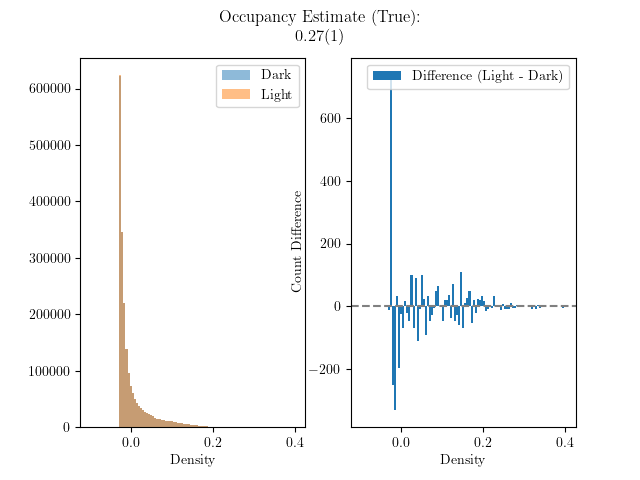

In [48]:
config = {
    "alpha": alpha,
    "number_bins": 100,
    "zoom_in": False,
    "alpha_xtr": 0.27
}
val_distributions(density_dark,density_light,config)

interactive(children=(IntSlider(value=0, description='f0', max=107), Output()), _dom_classes=('widget-interact…

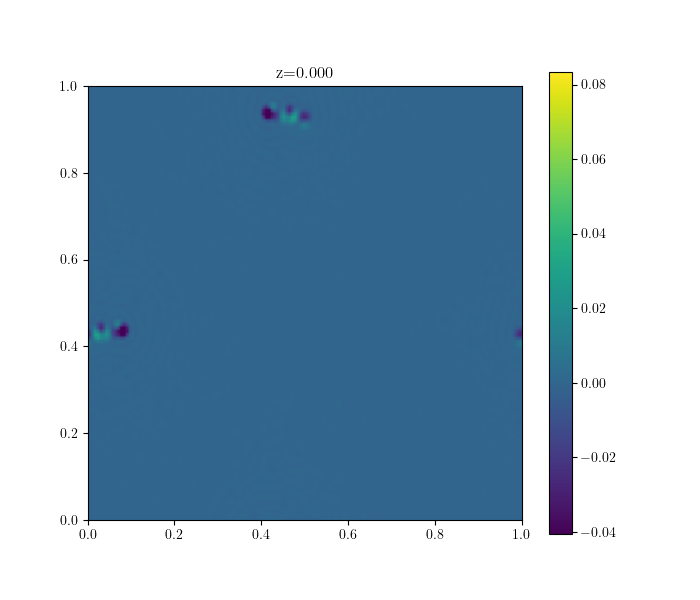

In [49]:
%matplotlib widget
_ = slice_3d(density_dark-density_light)